In [10]:
def estado_base_ising(
    J: float,
    h: float,
    n_q: int,
    periodic: bool = False
) -> tuple[float, Statevector]:

    if n_q < 1:
        raise ValueError("n_q debe ser al menos 1.")

    terminos = []

    for i in range(n_q - 1):
        terminos.append(("ZZ", [i, i + 1], -J))

    if periodic and n_q > 2:
        terminos.append(("ZZ", [n_q - 1, 0], -J))

    for i in range(n_q):
        terminos.append(("X", [i], -h))

    H = SparsePauliOp.from_sparse_list(
        terminos,
        num_qubits=n_q
    )

    eigenvalues, eigenvectors = np.linalg.eigh(H.to_matrix())

    energia_base = float(eigenvalues[0])
    estado_base = Statevector(eigenvectors[:, 0])

    return energia_base, estado_base

In [11]:
E_0, psi_0 = estado_base_ising(
    J=1.0,
    h=3,
    n_q=6
)

print("Energía base:", E_0)
print("Estado base:", psi_0)

Energía base: -18.41841803015973
Estado base: Statevector([0.18850587+0.j, 0.15709338+0.j, 0.13310637+0.j,
             0.15449644+0.j, 0.13137535+0.j, 0.11248511+0.j,
             0.12914584+0.j, 0.15415098+0.j, 0.13137535+0.j,
             0.10993529+0.j, 0.09529279+0.j, 0.11114948+0.j,
             0.12741869+0.j, 0.10964776+0.j, 0.12888223+0.j,
             0.15449644+0.j, 0.13310637+0.j, 0.11101553+0.j,
             0.09437765+0.j, 0.10964776+0.j, 0.09529279+0.j,
             0.08167762+0.j, 0.09414919+0.j, 0.11248511+0.j,
             0.12914584+0.j, 0.10817462+0.j, 0.09414919+0.j,
             0.10993529+0.j, 0.12888223+0.j, 0.11101553+0.j,
             0.13093892+0.j, 0.15709338+0.j, 0.15709338+0.j,
             0.13093892+0.j, 0.11101553+0.j, 0.12888223+0.j,
             0.10993529+0.j, 0.09414919+0.j, 0.10817462+0.j,
             0.12914584+0.j, 0.11248511+0.j, 0.09414919+0.j,
             0.08167762+0.j, 0.09529279+0.j, 0.10964776+0.j,
             0.09437765+0.j, 0.11101553

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector


def hamiltoniano_ising(
    J: float,
    h: float,
    n_q: int,
    periodic: bool = False
) -> SparsePauliOp:
    """
    Hamiltoniano de Ising con campo transverso:

        H = -J Σ_i Z_i Z_{i+1} - h Σ_i X_i
    """

    if n_q < 2:
        raise ValueError("n_q debe ser al menos 2.")

    terminos = []

    # Interacción ferromagnética
    for i in range(n_q - 1):
        terminos.append(("ZZ", [i, i + 1], -J))

    # Frontera periódica
    if periodic and n_q > 2:
        terminos.append(("ZZ", [n_q - 1, 0], -J))

    # Campo transversal
    for i in range(n_q):
        terminos.append(("X", [i], -h))

    return SparsePauliOp.from_sparse_list(
        terminos,
        num_qubits=n_q
    )


def estado_base_ising(
    J: float,
    h: float,
    n_q: int,
    periodic: bool = False
) -> Statevector:
    """
    Obtiene el estado base mediante diagonalización exacta.
    """

    H = hamiltoniano_ising(
        J=J,
        h=h,
        n_q=n_q,
        periodic=periodic
    )

    # Matriz densa hermítica
    H_matrix = np.asarray(H.to_matrix(), dtype=complex)

    # Diagonalización exacta
    eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)

    # Copia contigua para evitar:
    # "the given array is not contiguous"
    ground_state = np.ascontiguousarray(
        eigenvectors[:, 0],
        dtype=complex
    )

    return Statevector(ground_state)


def magnetizacion_z_cuadrada(n_q: int) -> SparsePauliOp:
    r"""
    Construye el operador:

                  1
        M_z = -------- Σ_i Z_i
                 n_q

    y devuelve M_z².

    Usamos:

        M_z² = I/n_q + (2/n_q²) Σ_{i<j} Z_i Z_j
    """

    terminos = [
        ("I" * n_q, 1.0 / n_q)
    ]

    for i in range(n_q):
        for j in range(i + 1, n_q):
            pauli = ["I"] * n_q

            # Para etiquetas completas de Pauli, Qiskit usa
            # el orden q_{n-1} ... q_1 q_0
            pauli[n_q - 1 - i] = "Z"
            pauli[n_q - 1 - j] = "Z"

            terminos.append(
                ("".join(pauli), 2.0 / n_q**2)
            )

    return SparsePauliOp.from_list(terminos)


def barrido_magnetizacion(
    n_q: int,
    J: float = 1.0,
    h_min: float = 0.0,
    h_max: float = 2.0,
    puntos: int = 101,
    periodic: bool = False
):
    """
    Calcula <M_z²> para diferentes valores de h/J.
    """

    if J == 0:
        raise ValueError("J no puede ser cero porque graficamos h/J.")

    valores_h = np.linspace(h_min, h_max, puntos)
    valores_h_sobre_J = valores_h / J

    Mz2 = magnetizacion_z_cuadrada(n_q)

    valores_mz2 = []

    for h in valores_h:
        psi_0 = estado_base_ising(
            J=J,
            h=h,
            n_q=n_q,
            periodic=periodic
        )

        esperanza = psi_0.expectation_value(Mz2)

        # El resultado debería ser real.
        # real_if_close elimina errores numéricos imaginarios ~10^-16.
        esperanza = np.real_if_close(esperanza)

        valores_mz2.append(float(np.real(esperanza)))

    return valores_h_sobre_J, np.array(valores_mz2)


def graficar_magnetizacion(
    n_q: int,
    puntos: int = 101,
    periodic: bool = False
):
    J = 1.0

    h_sobre_J, mz2 = barrido_magnetizacion(
        n_q=n_q,
        J=J,
        h_min=0.0,
        h_max=2.0,
        puntos=puntos,
        periodic=periodic
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        h_sobre_J,
        mz2,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=rf"$N={n_q}$"
    )

    # Punto crítico del modelo infinito: h/J = 1
    plt.axvline(
        x=1.0,
        linestyle="--",
        label=r"Punto crítico $h/J=1$"
    )

    plt.xlabel(r"$h/J$")
    plt.ylabel(r"$\langle M_z^2\rangle$")
    plt.title(
        "Magnetización longitudinal cuadrática\n"
        "Modelo de Ising con campo transverso"
    )

    plt.xlim(0, 2)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

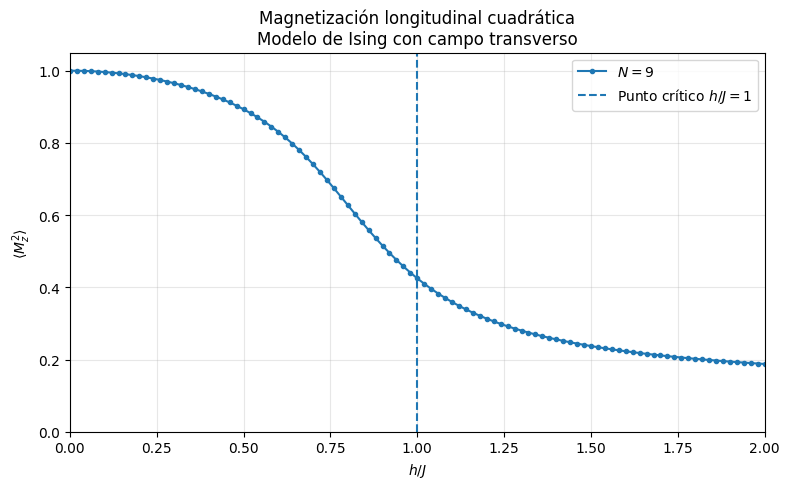

In [13]:
graficar_magnetizacion(
    n_q=9,
    puntos=101,
    periodic=False
)

In [14]:
def magnetizacion_x(n_q: int) -> SparsePauliOp:
    r"""
    Operador de magnetización transversal promedio:
        M_x = (1 / n_q) Σ_i X_i
    """

    terminos = [
        ("X", [i], 1.0 / n_q)
        for i in range(n_q)
    ]

    return SparsePauliOp.from_sparse_list(
        terminos,
        num_qubits=n_q
    )

def correlacion_zz_vecinos(
    n_q: int,
    periodic: bool = False
) -> SparsePauliOp:
    r"""
    Correlación promedio entre primeros vecinos:

        C_zz = (1 / N_b) Σ_<i,j> Z_i Z_j

    donde N_b es el número de enlaces.
    """

    if n_q < 2:
        raise ValueError("n_q debe ser al menos 2.")

    terminos = [
        ("ZZ", [i, i + 1], 1.0)
        for i in range(n_q - 1)
    ]

    if periodic:
        terminos.append(
            ("ZZ", [n_q - 1, 0], 1.0)
        )

    numero_enlaces = len(terminos)

    terminos_normalizados = [
        (pauli, indices, coeficiente / numero_enlaces)
        for pauli, indices, coeficiente in terminos
    ]

    return SparsePauliOp.from_sparse_list(
        terminos_normalizados,
        num_qubits=n_q
    )

def barrido_magnetizacion_x_y_correlacion_zz(
    n_q: int,
    J: float = 1.0,
    h_min: float = 0.0,
    h_max: float = 2.0,
    puntos: int = 101,
    periodic: bool = False
):
    if J == 0:
        raise ValueError("J no puede ser cero porque graficamos h/J.")

    valores_h = np.linspace(h_min, h_max, puntos)
    valores_h_sobre_J = valores_h / J

    Mx = magnetizacion_x(n_q)

    Czz = correlacion_zz_vecinos(
        n_q=n_q,
        periodic=periodic
    )

    valores_mx = []
    valores_czz = []

    for h in valores_h:
        psi_0 = estado_base_ising(
            J=J,
            h=h,
            n_q=n_q,
            periodic=periodic
        )

        mx = psi_0.expectation_value(Mx)
        czz = psi_0.expectation_value(Czz)

        valores_mx.append(
            float(np.real(np.real_if_close(mx)))
        )

        valores_czz.append(
            float(np.real(np.real_if_close(czz)))
        )

    return (
        valores_h_sobre_J,
        np.asarray(valores_mx),
        np.asarray(valores_czz)
    )

def graficar_magnetizacion_x(
    n_q: int,
    puntos: int = 101,
    periodic: bool = False
):
    h_sobre_J, mx, _ = barrido_magnetizacion_x_y_correlacion_zz(
        n_q=n_q,
        J=1.0,
        h_min=0.0,
        h_max=2.0,
        puntos=puntos,
        periodic=periodic
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        h_sobre_J,
        mx,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=rf"$N={n_q}$"
    )

    plt.axvline(
        1.0,
        linestyle="--",
        label=r"Punto crítico $h/J=1$"
    )

    plt.xlabel(r"$h/J$")
    plt.ylabel(r"$\langle M_x\rangle$")
    plt.title(
        "Magnetización transversal\n"
        "Modelo de Ising con campo transverso"
    )

    plt.xlim(0, 2)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def graficar_correlacion_zz(
    n_q: int,
    puntos: int = 101,
    periodic: bool = False
):
    h_sobre_J, _, czz = barrido_magnetizacion_x_y_correlacion_zz(
        n_q=n_q,
        J=1.0,
        h_min=0.0,
        h_max=2.0,
        puntos=puntos,
        periodic=periodic
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        h_sobre_J,
        czz,
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=rf"$N={n_q}$"
    )

    plt.axvline(
        1.0,
        linestyle="--",
        label=r"Punto crítico $h/J=1$"
    )

    plt.xlabel(r"$h/J$")
    plt.ylabel(
        r"$\frac{1}{N_b}"
        r"\sum_{\langle i,j\rangle}"
        r"\langle Z_iZ_j\rangle$"
    )

    plt.title(
        "Correlación longitudinal entre vecinos\n"
        "Modelo de Ising con campo transverso"
    )

    plt.xlim(0, 2)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



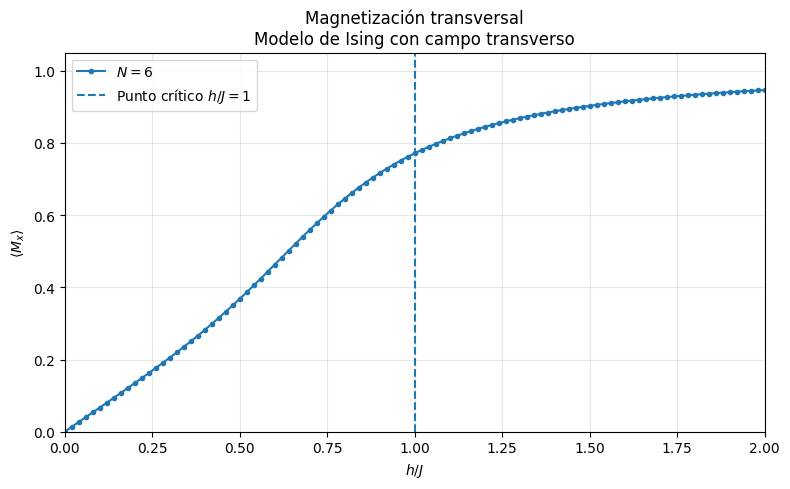

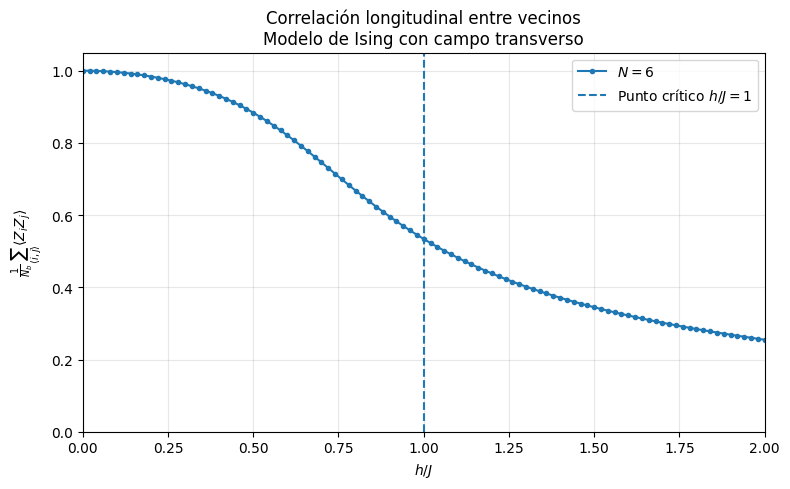

In [15]:
graficar_magnetizacion_x(
    n_q=6,
    puntos=101,
    periodic=False
)

graficar_correlacion_zz(
    n_q=6,
    puntos=101,
    periodic=False
)